# 이상지질혈증 예측 - XGBoost Feature Engineering 실험

- 타겟: `이상지질혈증유병` (0: 없음 / 1: 있음)
- 모델: XGBoost (Optuna 최적 파라미터 고정)
- 데이터: hn_all_preprocessed_v2.csv
- Threshold: 0.45 고정
- 목적: **피처 추가·제거 실험으로 성능 변화 확인**
- 검증: Stratified 5-Fold CV

In [241]:
import os
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ── 경로 설정 (상대 경로) ──────────────────────────────────
CURRENT_DIR = os.path.dirname(os.path.abspath(""))
BASE_DIR = os.path.join(CURRENT_DIR, "..")
DATA_PATH = os.path.join(BASE_DIR, "data", "hn_all_preprocessed_v2.csv")
FEATURES_DIR = os.path.join(BASE_DIR, "features")
NPY_DIR = os.path.join(BASE_DIR, "outputs", "oof")
sys.path.insert(0, FEATURES_DIR)

RANDOM_STATE = 42
THRESHOLD = 0.45

## 1. 데이터 로드

In [242]:
df = pd.read_csv(DATA_PATH)
print(f"로드 완료 | shape: {df.shape}")

로드 완료 | shape: (19765, 31)


## 2. ✏️ Feature Engineering 설정

> **실험 방법:** 추가하고 싶은 피처 함수의 주석을 해제하세요.
> 순서 중요: `add_age_bin` → `add_family_sum` → 나머지

In [243]:
# # ── 피처 엔지니어링 함수 import ──────────────────────────────
# from fe_age_bin       import add_age_bin           # 나이_구간
# from fe_age_bin5      import add_age_bin5           # 나이_구간(5구간)
# from fe_family_sum    import add_family_sum         # 가족력_합계
# from fe_bmi_bin       import add_bmi_bin            # BMI_구간
# from fe_alcohol       import add_alcohol_load       # 음주_총부하
# from fe_exercise      import add_exercise_total     # 총운동일수
# from fe_body          import add_body_features      # 체중_키_비율, BMI_나이_상호작용
# from fe_age_family    import add_age_family_interaction  # 나이_고혈압가족력 등
#
# # ── 적용할 피처 선택 (주석 해제 = 적용) ──────────────────────
# df = add_age_bin(df, drop_original=False)                  # 나이_구간
# # df = add_age_bin5(df, drop_original=True)                 # 나이_5구간
#
# # 가족력 실험
# df = add_family_sum(df, diabetes=True, hypertension=False, dyslipidemia=False,
#                     drop_original=False) # 가족력_3종_제거 + 가족력_합산
# # df = df.drop(columns=[
# #     '고혈압가족력_부', '고혈압가족력_모', '고혈압가족력_형제',
# #     '당뇨가족력_부', '당뇨가족력_모', '당뇨가족력_형제',]) # 가족력 실험
#
# # BMI 실험
# # df = add_bmi_bin(df, korean_standard=True, drop_original=True) # BMI_구간(True: 한국인 기준, False: WHO 기준)
# # df = df.drop(columns=[ '키', '체중',]) # BMI 실험
#
# df = add_alcohol_load(df, drop_original=True)  # 음주_총부하 (필요 시 해제)
# df = add_exercise_total(df, drop_original=True)         # 총운동일수 (필요 시 해제)
# df = add_body_features(df, weight_height_ratio=True, bmi_age_interaction=False, drop_original=False) # 체형 복합 (필요 시 해제)
# # df = add_age_family_interaction(df, hypertension=False, diabetes=True)   # 나이×가족력 (필요 시 해제)
#
# print(f'\n피처 엔지니어링 완료 | shape: {df.shape}')

[fe_age_bin] '나이_구간' 추가 완료
  분포:
나이_구간
0    3976
1    2949
2    3580
3    9260
  (0: 19~39세 / 1: 40~49세 / 2: 50~59세 / 3: 60세 이상)
[fe_family_sum] '당뇨가족력_합계' 추가   | 분포: {0: 12459, 1: 4181, 2: 897, 3: 137, 8: 234, 9: 463, 10: 198, 11: 81, 17: 22, 18: 312, 19: 199, 26: 54, 27: 528}
[fe_alcohol] '음주_총부하' 추가 완료
  유효값: 19307건 | NaN(비음주/결측): 458건
  분포: min=0.0 mean=5.60 max=25.0
[fe_alcohol] 원본 제거: ['음주빈도_enc', '음주량_enc']
[fe_exercise] '총운동일수' 추가 완료
  범위: 2.0~108.0일
  평균: 15.80일
[fe_exercise] 원본 제거: ['걷기일수', '근력운동일수']
[fe_body] '체중_키_비율' 추가 완료 | mean=0.3954

피처 엔지니어링 완료 | shape: (19765, 32)


## 3. 피처 / 타겟 분리

In [244]:
TARGET = "이상지질혈증유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)
neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos

print(f"샘플 수: {len(y)}  |  정상: {neg}  |  이상지질혈증: {pos}")
print(f"사용 피처 수: {X.shape[1]}")
print(f"피처 목록: {list(X.columns)}")

샘플 수: 19175  |  정상: 13732  |  이상지질혈증: 5443
사용 피처 수: 29
피처 목록: ['성별', '나이', '현재흡연', '고혈압가족력_부', '고혈압가족력_모', '고혈압가족력_형제', '고지혈증가족력_부', '고지혈증가족력_모', '고지혈증가족력_형제', '당뇨가족력_부', '당뇨가족력_모', '당뇨가족력_형제', '키', '체중', 'BMI', '직업_관리전문', '직업_사무', '직업_서비스판매', '직업_농림어업', '직업_기능노무', '직업_주부학생', '직업_무직', '직업_작업미상', '과거음주_현재금주', '나이_구간', '당뇨가족력_합계', '음주_총부하', '총운동일수', '체중_키_비율']


## 4. Optuna 최적 파라미터 설정

In [245]:
best_params = {
    "n_estimators": 487,
    "learning_rate": 0.08927180304353628,
    "max_depth": 7,
    "min_child_weight": 6,
    "subsample": 0.6624074561769746,
    "colsample_bytree": 0.662397808134481,
    "gamma": 0.05808361216819946,
    "reg_alpha": 0.8661761457749352,
    "reg_lambda": 2.002787529358022,
    "scale_pos_weight": ratio,
    "eval_metric": "auc",
    "early_stopping_rounds": 50,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0,
}
print("파라미터 설정 완료")

파라미터 설정 완료


## 5. Stratified 5-Fold CV

In [246]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
fold_scores = []

print("=" * 65)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model = xgb.XGBClassifier(**best_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba
    pred = (proba >= THRESHOLD).astype(int)
    cm_f = confusion_matrix(y_val, pred)
    fold_scores.append(
        {
            "fold": fold,
            "auc": roc_auc_score(y_val, proba),
            "f1": f1_score(y_val, pred),
            "recall": recall_score(y_val, pred),
            "precision": precision_score(y_val, pred),
            "fp": int(cm_f[0, 1]),
            "best_iter": model.best_iteration,
        }
    )
    print(
        f"  Fold {fold} | AUC: {fold_scores[-1]['auc']:.4f} | "
        f"Recall: {fold_scores[-1]['recall']:.4f} | "
        f"F1: {fold_scores[-1]['f1']:.4f} | "
        f"best_iter: {model.best_iteration}"
    )

scores_df = pd.DataFrame(fold_scores)
print("=" * 65)
print(
    f"  평균   | AUC: {scores_df.auc.mean():.4f}±{scores_df.auc.std():.4f} "
    f"| Recall: {scores_df.recall.mean():.4f}±{scores_df.recall.std():.4f} "
    f"| F1: {scores_df.f1.mean():.4f}±{scores_df.f1.std():.4f}"
)

  Fold 1 | AUC: 0.7759 | Recall: 0.8529 | F1: 0.5707 | best_iter: 43
  Fold 2 | AUC: 0.7990 | Recall: 0.8539 | F1: 0.5898 | best_iter: 45
  Fold 3 | AUC: 0.7814 | Recall: 0.8595 | F1: 0.5758 | best_iter: 32
  Fold 4 | AUC: 0.7898 | Recall: 0.8531 | F1: 0.5843 | best_iter: 29
  Fold 5 | AUC: 0.7835 | Recall: 0.8567 | F1: 0.5864 | best_iter: 54
  평균   | AUC: 0.7859±0.0088 | Recall: 0.8552±0.0028 | F1: 0.5814±0.0079


## 6. OOF proba 저장 (.npy)

In [247]:
os.makedirs(NPY_DIR, exist_ok=True)
npy_path = os.path.join(NPY_DIR, "oof_proba_HL_xgboost_v3_fe.npy")
oof_array = np.stack([oof_proba, y.values], axis=1)
np.save(npy_path, oof_array)
print(f"저장 완료 → {npy_path}")
loaded = np.load(npy_path)
print(f"로드 확인: shape={loaded.shape}, 일치={np.allclose(oof_array, loaded)}")

저장 완료 → /Users/Jiyeon/Desktop/final_project/ML/model/../outputs/oof/oof_proba_HL_xgboost_v3_fe.npy
로드 확인: shape=(19175, 2), 일치=True


## 7. OOF 성능 & 기준 모델 비교

In [248]:
pred_oof = (oof_proba >= THRESHOLD).astype(int)
cm = confusion_matrix(y, pred_oof)

oof_auc = roc_auc_score(y, oof_proba)
oof_rec = recall_score(y, pred_oof)
oof_prec = precision_score(y, pred_oof)
oof_f1 = f1_score(y, pred_oof)
oof_acc = float((pred_oof == y).mean())

# 기준 모델 (FE 없음, Optuna)
BASE = {"auc": 0.7890, "recall": 0.8508, "precision": 0.4478, "f1": 0.5868, "acc": 0.6604, "fp": 5711, "fn": 812}

print("=" * 55)
print(f"  {'지표':<12}  {'기준 모델':>12}  {'FE 적용':>10}  변화")
print("=" * 55)
for label, base_v, cur_v in [
    ("AUC-ROC", BASE["auc"], oof_auc),
    ("Recall", BASE["recall"], oof_rec),
    ("Precision", BASE["precision"], oof_prec),
    ("F1-score", BASE["f1"], oof_f1),
    ("Accuracy", BASE["acc"], oof_acc),
]:
    d = cur_v - base_v
    arrow = "▲" if d > 0 else ("▼" if d < 0 else "─")
    print(f"  {label:<12}  {base_v:>12.4f}  {cur_v:>10.4f}  {arrow} {abs(d):.4f}")
print(
    f"  {'FP':<12}  {BASE['fp']:>12}  {cm[0, 1]:>10}  {'▼' if cm[0, 1] < BASE['fp'] else '▲'} {abs(cm[0, 1] - BASE['fp'])}"
)
print(
    f"  {'FN':<12}  {BASE['fn']:>12}  {cm[1, 0]:>10}  {'▼' if cm[1, 0] < BASE['fn'] else '▲'} {abs(cm[1, 0] - BASE['fn'])}"
)
print("=" * 55)
print("\n[분류 리포트]")
print(classification_report(y, pred_oof, target_names=["정상(0)", "이상지질혈증(1)"]))

  지표                   기준 모델       FE 적용  변화
  AUC-ROC             0.7890      0.7853  ▼ 0.0037
  Recall              0.8508      0.8552  ▲ 0.0044
  Precision           0.4478      0.4403  ▼ 0.0075
  F1-score            0.5868      0.5813  ▼ 0.0055
  Accuracy            0.6604      0.6503  ▼ 0.0101
  FP                    5711        5917  ▲ 206
  FN                     812         788  ▼ 24

[분류 리포트]
              precision    recall  f1-score   support

       정상(0)       0.91      0.57      0.70     13732
   이상지질혈증(1)       0.44      0.86      0.58      5443

    accuracy                           0.65     19175
   macro avg       0.67      0.71      0.64     19175
weighted avg       0.78      0.65      0.67     19175



## 8. Confusion Matrix

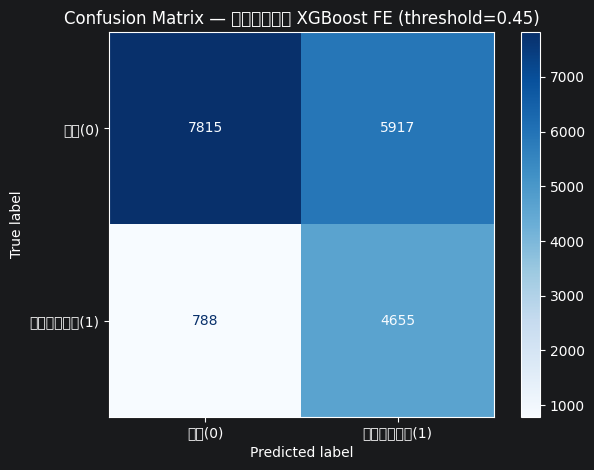

In [249]:
disp = ConfusionMatrixDisplay(cm, display_labels=["정상(0)", "이상지질혈증(1)"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — 이상지질혈증 XGBoost FE (threshold={THRESHOLD})")
plt.tight_layout()
plt.show()

## 9. Feature Importance (XGBoost, 5-Fold 평균)

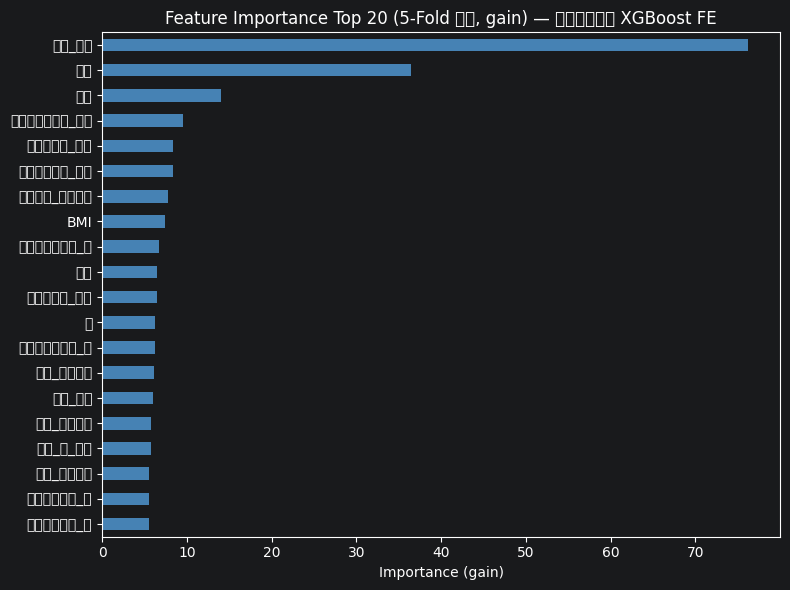

   1. 나이_구간: 76.2
   2. 나이: 36.4
   3. 성별: 14.1
   4. 고지혈증가족력_형제: 9.6
   5. 당뇨가족력_형제: 8.4
   6. 고혈압가족력_형제: 8.4
   7. 과거음주_현재금주: 7.7
   8. BMI: 7.5
   9. 고지혈증가족력_모: 6.8
  10. 체중: 6.5
  11. 당뇨가족력_합계: 6.4
  12. 키: 6.3
  13. 고지혈증가족력_부: 6.2
  14. 직업_농림어업: 6.2
  15. 직업_사무: 6.0
  16. 직업_관리전문: 5.8
  17. 체중_키_비율: 5.7
  18. 직업_주부학생: 5.5
  19. 고혈압가족력_모: 5.5
  20. 고혈압가족력_부: 5.5


In [250]:
fi_list = []
for fold, (tr_idx, val_idx) in enumerate(
    StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y), 1
):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    m = xgb.XGBClassifier(**best_params)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    gain = pd.Series(m.get_booster().get_score(importance_type="gain"))
    gain = gain.reindex(X.columns, fill_value=0)
    fi_list.append(gain)

fi = pd.DataFrame(fi_list).mean(axis=0).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
fi.head(20)[::-1].plot(kind="barh", color="steelblue")
plt.title("Feature Importance Top 20 (5-Fold 평균, gain) — 이상지질혈증 XGBoost FE")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.show()
for i, (feat, imp) in enumerate(fi.head(20).items(), 1):
    print(f"  {i:2d}. {feat}: {imp:.1f}")

## 10. SHAP 분석 (OOF 전체 기준)

SHAP Fold 1 완료
SHAP Fold 2 완료
SHAP Fold 3 완료
SHAP Fold 4 완료
SHAP Fold 5 완료


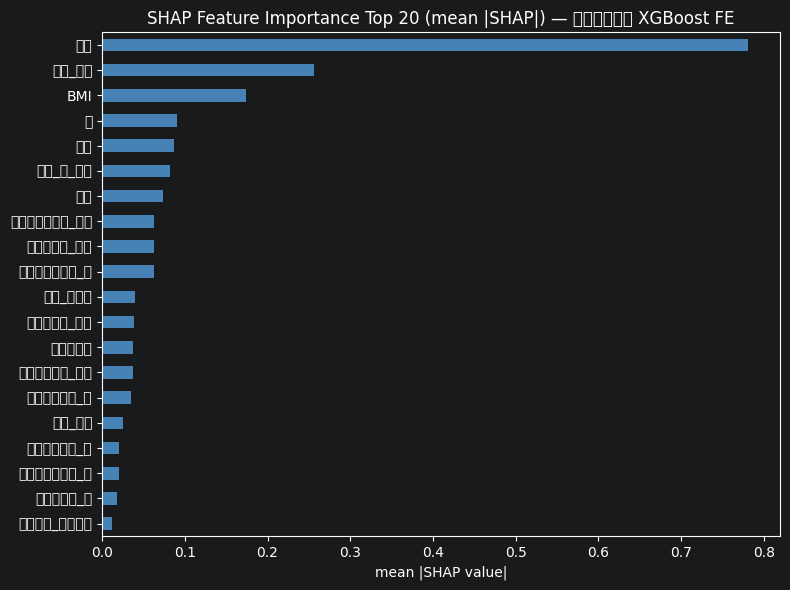

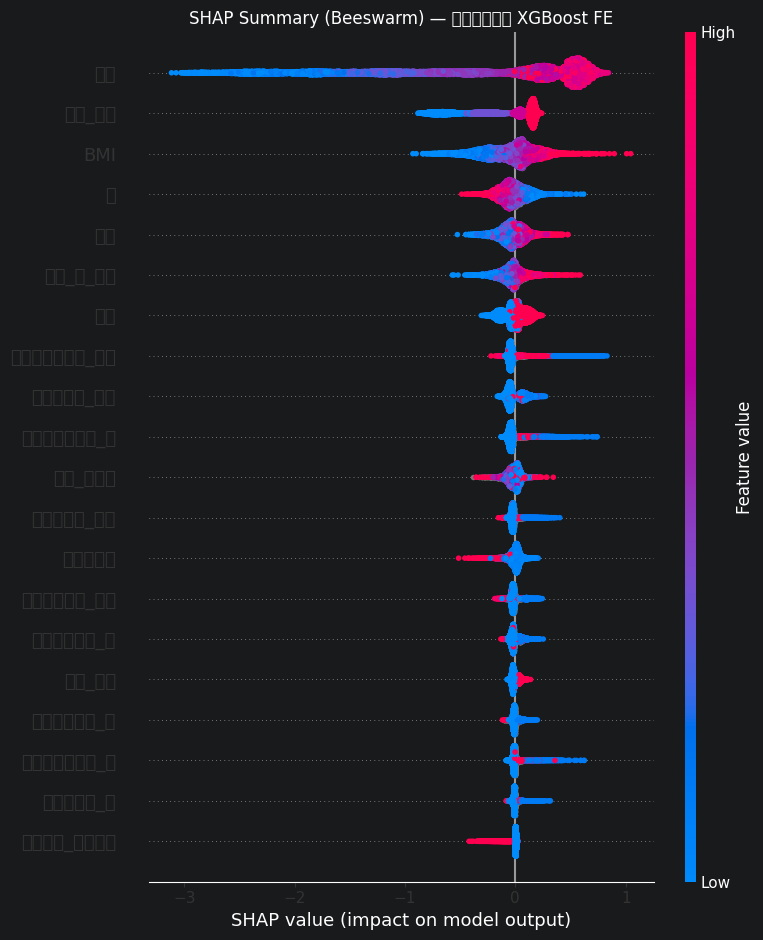

[SHAP Top 15]
   1. 나이: 0.7805
   2. 나이_구간: 0.2558
   3. BMI: 0.1739
   4. 키: 0.0905
   5. 체중: 0.0866
   6. 체중_키_비율: 0.0820
   7. 성별: 0.0738
   8. 고지혈증가족력_형제: 0.0633
   9. 당뇨가족력_합계: 0.0632
  10. 고지혈증가족력_모: 0.0631
  11. 음주_총부하: 0.0400
  12. 당뇨가족력_형제: 0.0385
  13. 총운동일수: 0.0370
  14. 고혈압가족력_형제: 0.0370
  15. 고혈압가족력_모: 0.0355


In [251]:
import shap

skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
shap_values = np.zeros(X.shape)

for fold, (tr_idx, val_idx) in enumerate(skf2.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    m = xgb.XGBClassifier(**best_params)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    explainer = shap.TreeExplainer(m)
    shap_values[val_idx] = explainer.shap_values(X_val)
    print(f"SHAP Fold {fold} 완료")

mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values(ascending=False)

# SHAP Bar
plt.figure(figsize=(8, 6))
mean_shap.head(20)[::-1].plot(kind="barh", color="steelblue")
plt.title("SHAP Feature Importance Top 20 (mean |SHAP|) — 이상지질혈증 XGBoost FE")
plt.xlabel("mean |SHAP value|")
plt.tight_layout()
plt.show()

# SHAP Beeswarm
shap.summary_plot(shap_values, X, plot_type="dot", max_display=20, show=False)
plt.title("SHAP Summary (Beeswarm) — 이상지질혈증 XGBoost FE", fontsize=12)
plt.tight_layout()
plt.show()

print("[SHAP Top 15]")
for i, (feat, val) in enumerate(mean_shap.head(15).items(), 1):
    print(f"  {i:2d}. {feat}: {val:.4f}")

## 11. DB 로그 저장

In [252]:
sys.path.insert(0, os.path.join(BASE_DIR))
from model_logger import ModelLogger

logger = ModelLogger(os.path.join(BASE_DIR, "model_result.db"))

base_cols = pd.read_csv(DATA_PATH).columns.tolist()
fe_cols = [c for c in X.columns if c not in base_cols]
fe_note = f"FE 적용: {fe_cols}" if fe_cols else "FE 없음"

run_id = logger.log_run(
    target_var="이상지질혈증",
    model_name="XGBoost",
    stage="fe_exp",
    hyperparams={
        "learning_rate": best_params["learning_rate"],
        "max_depth": best_params["max_depth"],
        "n_estimators": best_params["n_estimators"],
        "class_weight": {0: 1.0, 1: round(ratio, 4)},
        "min_child_weight": best_params["min_child_weight"],
        "subsample": best_params["subsample"],
        "colsample_bytree": best_params["colsample_bytree"],
        "gamma": best_params["gamma"],
        "reg_alpha": best_params["reg_alpha"],
        "reg_lambda": best_params["reg_lambda"],
    },
    data_info={
        "feature_count": X.shape[1],
        "train_test_split": "5-Fold CV",
        "scaling_method": "None",
    },
    oof_metrics={
        "accuracy": oof_acc,
        "recall": oof_rec,
        "precision": oof_prec,
        "f1_score": oof_f1,
        "auc_roc": oof_auc,
        "cm": cm.tolist(),
    },
    fold_scores=scores_df.to_dict("records"),
    top_features=gain.head(15).to_dict(),
    note=fe_note,
)
print(f"저장 완료 → run_id: {run_id}  |  {fe_note}")
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=121 | 이상지질혈증 XGBoost (fe_exp)
저장 완료 → run_id: 121  |  FE 적용: ['나이_구간', '당뇨가족력_합계', '음주_총부하', '총운동일수', '체중_키_비율']
 run_id          created_at target_var model_name             stage  auc_roc   recall  precision  f1_score  accuracy
    121 2026-05-20 15:05:44     이상지질혈증    XGBoost            fe_exp 0.785280 0.855227   0.440314  0.581330  0.650326
    120 2026-05-20 15:04:47     이상지질혈증    XGBoost            fe_exp 0.785628 0.858534   0.440517  0.582269  0.650326
    119 2026-05-20 15:03:06     이상지질혈증    XGBoost            fe_exp 0.785309 0.857799   0.440888  0.582424  0.650847
    118 2026-05-20 14:41:43     이상지질혈증    XGBoost            fe_exp 0.784737 0.855778   0.441558  0.582541  0.651838
    117 2026-05-20 14:40:01     이상지질혈증    XGBoost            fe_exp 0.785420 0.843101   0.445967  0.583360  0.658149
    116 2026-05-20 14:37:23     이상지질혈증    XGBoost            fe_exp 0.787115 0.854859   0.443861  0.584328  0.654759
    115 2026-05-20 14:36:49     이상지질혈증 